In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../'))
sys.path.insert(0, src_dir)
import src


/import/taiji1/bhar9988/code/DDC/WRCircuit.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from jax.lib import xla_bridge
import jax
print(xla_bridge.get_backend().platform)
name = "cuDNN"
jax._src.lib.cuda_versions.cudnn_get_version()
# jax._src.lib.cuda_versions.cudnn_build_version()
jax.default_device = jax.devices("cpu")[0]

cpu


In [4]:
from src.models.balanced import FNSPopulations
num_neurons = 50000
FNSnet = FNSPopulations(num_neurons, epsilon=0.1, D=2.0, nu_hat=10.0, g=0.2, J=1)
FNSnet.to_dict()

ImportError: cannot import name 'FNSPopulations' from 'src.models.balanced' (/import/taiji1/bhar9988/code/DDC/WRCircuit.jl/src/models/balanced.py)

In [4]:
# * Try update some parameters
FNSnet.E.tau = 20.0

In [5]:
FNSnet.to_dict()

{'FNSPopulations': {'epsilon': 0.1,
  'D': 2.0,
  'nu': 2.5,
  'g': 0.2,
  'J': 1,
  'populations': {'E': {'V_rest': 0.0,
    'V_reset': 10.0,
    'V_th': 20,
    'tau': 20.0,
    'R': 1,
    'ref_var': False,
    'tau_ref': 2.0,
    'embedding': {'ClusteredPositions': {'center': (-1.5, 0), 'radius': 1}}},
   'I': {'V_rest': 0.0,
    'V_reset': 10.0,
    'V_th': 20,
    'tau': 20,
    'R': 1,
    'ref_var': False,
    'tau_ref': 2.0,
    'embedding': {'ClusteredPositions': {'center': (1.5, 0), 'radius': 1}}}},
  'synapses': {'E2E': {'pre': 'LIFNeuron0',
    'post': 'LIFNeuron0',
    'delay_step': 19,
    'g_max': 1},
   'E2I': {'pre': 'LIFNeuron0',
    'post': 'LIFNeuron1',
    'delay_step': 19,
    'g_max': 1},
   'I2E': {'pre': 'LIFNeuron1',
    'post': 'LIFNeuron0',
    'delay_step': 19,
    'g_max': -0.2},
   'I2I': {'pre': 'LIFNeuron1',
    'post': 'LIFNeuron1',
    'delay_step': 19,
    'g_max': -0.2}}}}

In [6]:
if np.product(FNSnet.E.size) <= 100:
    E2E = FNSnet.E2E.conn.require("conn_mat")
    I2E = FNSnet.I2E.conn.require("conn_mat")
    E2I = FNSnet.E2I.conn.require("conn_mat")
    I2I = FNSnet.I2I.conn.require("conn_mat")
    fullconn = np.block([
        [E2E, E2I],  # Top row: E->E and E->I
        [I2E, I2I]   # Bottom row: I->E and I->I
    ])
    positions = np.concatenate((FNSnet.E.positions, FNSnet.I.positions))

    num_E = len(FNSnet.E.positions)
    num_I = len(FNSnet.I.positions)
    node_colors = ['g'] * num_E + ['r'] * num_I

    G = nx.from_numpy_array(fullconn, create_using=nx.DiGraph())

    nx.draw_networkx_nodes(
        G,
        pos=positions,
        node_color=node_colors,
        node_size=20,
    )

    # Get the indices of edges
    sources, targets = np.nonzero(fullconn)

    # Determine if source and target nodes are E or I
    node_types = np.array(['g'] * num_E + ['r'] * num_I)
    source_types = node_types[sources]
    target_types = node_types[targets]

    # Set edge colors based on node types
    edge_colors = np.full(len(sources), 'b')  # Default color for between-population edges
    edge_colors[(source_types == 'g') & (target_types == 'g')] = 'g'  # E->E edges
    edge_colors[(source_types == 'r') & (target_types == 'r')] = 'r'  # I->I edges

    # Draw all edges at once with their respective colors
    nx.draw_networkx_edges(
        G,
        pos=positions,
        edgelist=list(zip(sources, targets)),
        connectionstyle="arc3,rad=0.5",
        edge_color=edge_colors,
        width=0.5,
        alpha=0.1
    )


In [4]:
T = 1000.0
FNSnet.stimulus = bp.dyn.PoissonInput(FNSnet.Ein.input, np.prod(FNSnet.E.size), 30.0, 32.0)
runner = bp.DSRunner(
    FNSnet,
    monitors=["E.spike", "I.spike", "E.V", "I.V"],
    jit = True
)
runner.run(T)
t = runner.mon["ts"].view()  # [1000:]
Xe = runner.mon["E.spike"].view()  # [1000:]
Xi = runner.mon["I.spike"].view()  # [1000:]
Ve = runner.mon["E.V"].view()  # [1000:]
Vi = runner.mon["I.V"].view()  # [1000:]

Predict 10000 steps: : 100%|██████████| 10000/10000 [00:08<00:00, 1119.91it/s]


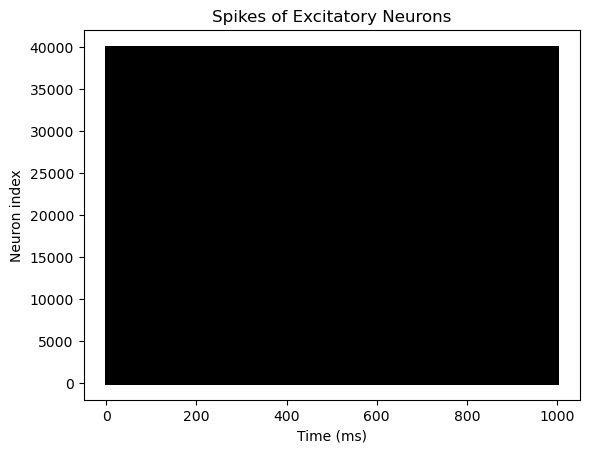

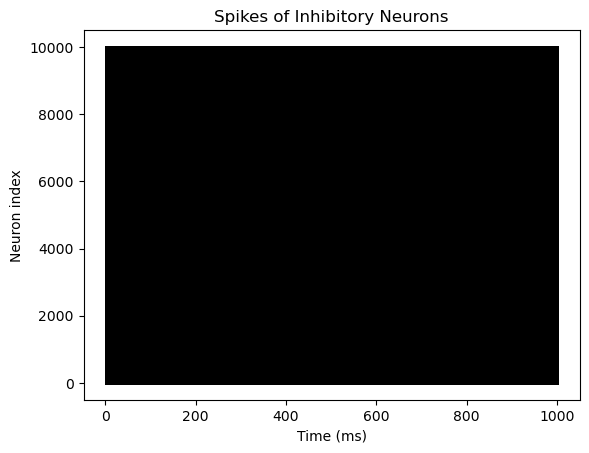

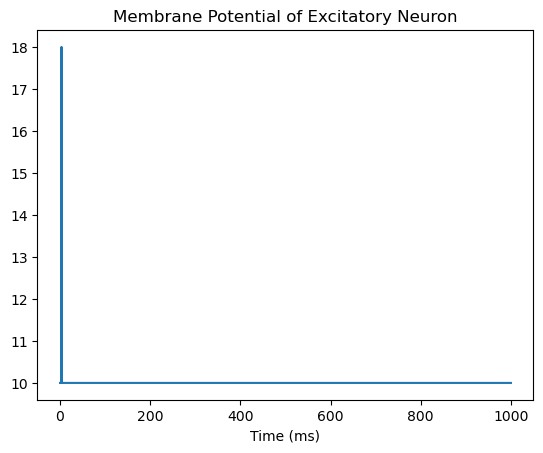

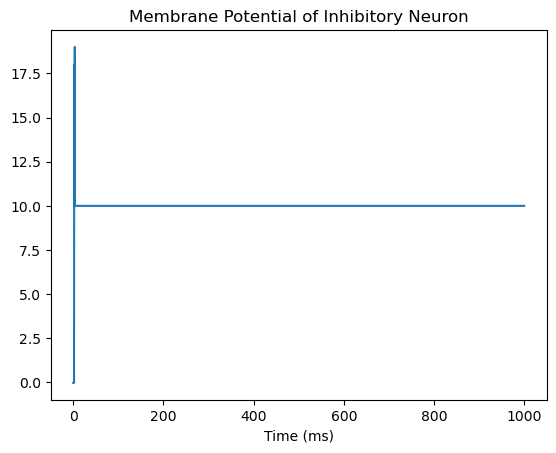

In [8]:
bp.visualize.raster_plot(t, Xe, title="Spikes of Excitatory Neurons", show=True)
bp.visualize.raster_plot(t, Xi, title="Spikes of Inhibitory Neurons", show=True)
bp.visualize.line_plot(t, Ve[:, 2], title="Membrane Potential of Excitatory Neuron", show=True)
bp.visualize.line_plot(t, Vi[:, 2], title="Membrane Potential of Inhibitory Neuron", show=True)